In [2]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

100%|===================| 999/1000 [06:52<00:00]        

SHAP done: 411.5885651111603 s
shape: (500, 105, 2)


C:\Users\sathi\AppData\Local\Temp\ipykernel_20548\1364434652.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


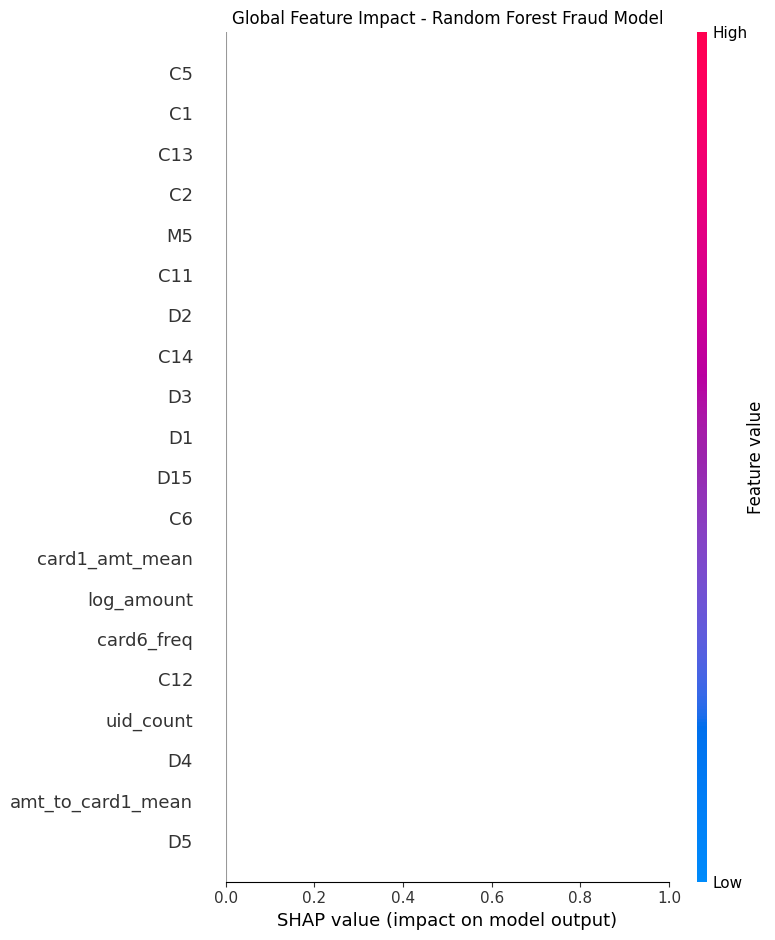


Top 20 features by mean |SHAP|:
  C5                                  0.0042
  C1                                  0.0040
  C13                                 0.0028
  C2                                  0.0027
  M5                                  0.0025
  C11                                 0.0023
  D2                                  0.0019
  C14                                 0.0019
  D3                                  0.0019
  D1                                  0.0018
  D15                                 0.0017
  C6                                  0.0017
  card1_amt_mean                      0.0017
  log_amount                          0.0016
  card6_freq                          0.0015
  C12                                 0.0014
  uid_count                           0.0013
  D4                                  0.0013
  amt_to_card1_mean                   0.0012
  D5                                  0.0012


['../../models/shap_values_sample.pkl']

In [ ]:
# Load model and feature cols
model=joblib.load('../../models/fraud_model.pkl')
feat_cols=joblib.load('../../models/feature_cols.pkl')
X_test=joblib.load("../../models/X_test.pkl")
X_test=np.asarray(X_test,dtype=np.float64)

# Load training data for background — correct approach
X_train=joblib.load("../../models/X_train.pkl")
X_train=np.asarray(X_train,dtype=np.float64)

np.random.seed(35)  # match model's random_state
background=X_train[np.random.choice(len(X_train),100,replace=False)]

X_sample=X_test[:500]

explainer=shap.TreeExplainer(model,data=background,feature_perturbation="interventional")

t0=time.time()
shap_values=explainer.shap_values(X_sample,check_additivity=False)
print("SHAP done:", time.time() - t0,"s")

sv=np.array(shap_values)
print("shape:",sv.shape)
shap_fraud=sv[:,:,1]

plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_fraud,
    pd.DataFrame(X_sample, columns=feat_cols),
    plot_type='beeswarm',
    max_display=20,
    show=False
)
plt.title("Global Feature Impact - Random Forest Fraud Model")
plt.tight_layout()
plt.savefig('../../outputs/shap_beeswarm_global.png',dpi=200)
plt.show()

print("\nTop 20 features by mean |SHAP|:")
mean_abs=np.abs(shap_fraud).mean(axis=0)
top_idx=np.argsort(mean_abs)[::-1][:20]
for i in top_idx:
    print(f"{feat_cols[i]:<35} {mean_abs[i]:.4f}")

joblib.dump(explainer,'../../models/shap_explainer.pkl')
joblib.dump(shap_fraud,'../../models/shap_values_sample.pkl')

In [3]:
print(shap_fraud[:5, :5])  # sanity check — are these non-zero, reasonable numbers?
print(shap_fraud.min(), shap_fraud.max(), shap_fraud.mean())

[[-4.76727066e-04  5.34942394e-04 -5.17026429e-04  2.64082768e-04
  -4.68849873e-04]
 [ 7.69768189e-04 -1.38260582e-03  1.54635718e-03  9.24379545e-04
  -2.65481948e-04]
 [-3.27725572e-04  1.83311440e-04 -7.53523455e-04 -1.53823120e-03
  -3.40957584e-04]
 [-2.64183650e-04  9.61913787e-05 -6.18375316e-04  8.67987832e-05
  -4.48901491e-04]
 [-6.13047255e-04 -5.12842690e-04 -2.94344128e-03 -7.15592235e-04
  -7.89756420e-04]]
-0.02060803459198052 0.09800849811161504 0.00010685714359674776


In [4]:
mean_abs_all = np.abs(shap_fraud).mean(axis=0)
ranking = sorted(zip(feat_cols, mean_abs_all), key=lambda x: -x[1])

for feat in ['email_domain_mismatch', 'purchaser_email_risk', 'amount_to_card_mean', 'day_of_week', 'hour']:
    if feat in feat_cols:
        rank = [i for i, (f, v) in enumerate(ranking) if f == feat][0]
        val = dict(ranking)[feat]
        print(f"{feat:<30} rank #{rank+1:3d}  mean|SHAP|={val:.5f}")
    else:
        print(f"{feat:<30} NOT IN feat_cols")

email_domain_mismatch          rank # 37  mean|SHAP|=0.00063
purchaser_email_risk           rank # 77  mean|SHAP|=0.00024
amount_to_card_mean            rank # 21  mean|SHAP|=0.00112
day_of_week                    rank # 48  mean|SHAP|=0.00051
hour                           rank # 33  mean|SHAP|=0.00079


0.51.0


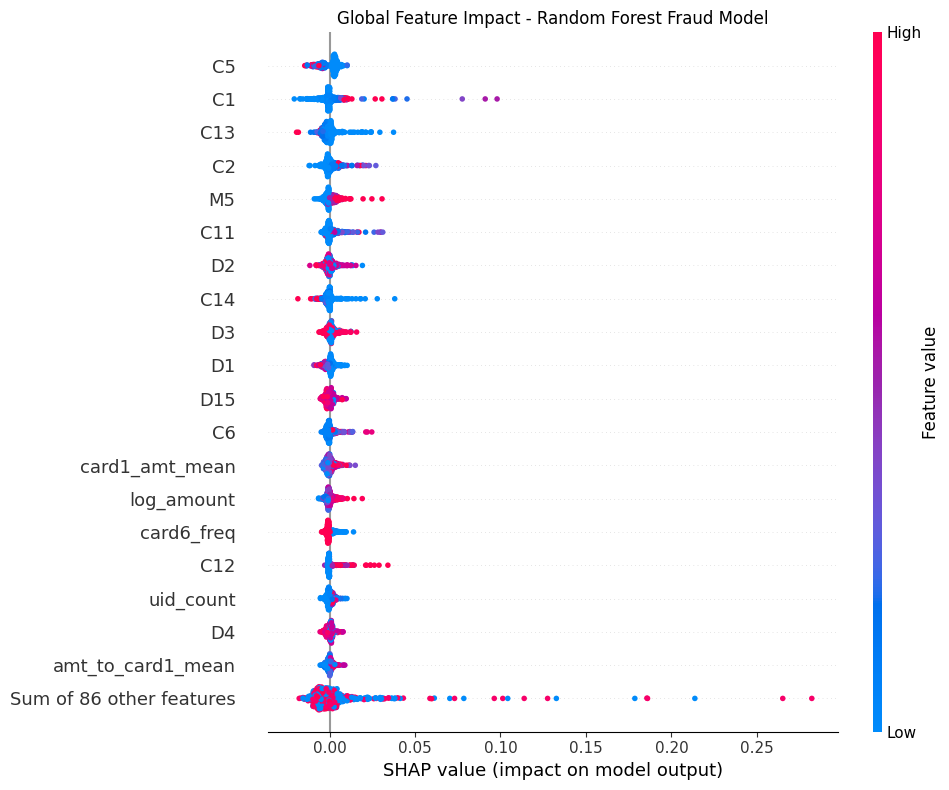

In [6]:
print(shap.__version__)

explanation=shap.Explanation(
    values=shap_fraud,
    data=X_sample,
    feature_names=feat_cols
)

shap.plots.beeswarm(explanation, max_display=20, show=False)
fig=plt.gcf()
fig.set_size_inches(10, 8)
plt.title("Global Feature Impact - Random Forest Fraud Model")
plt.tight_layout()
plt.savefig('../../outputs/shap_beeswarm_global.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
idx = feat_cols.index('email_domain_mismatch')
vals = shap_fraud[:, idx]
feat_vals = X_sample[:, idx]
print("mismatch=1 mean SHAP:", vals[feat_vals==1].mean())
print("mismatch=0 mean SHAP:", vals[feat_vals==0].mean())

mismatch=1 mean SHAP: -0.00038473946047497314
mismatch=0 mean SHAP: 0.0011096563697364091
